# A03: Sampling
-------------
**Dr. Dave Wanik - Operations and Information Management - University of Connecticut**

For this assignment, I'd like you to apply the topics of  undersampling, oversampling and SMOTE to a toy dataset to see if you get better performance by using these sampling methods. In my experience, sampling helps sometimes but not all times.

# Data
Everybody will have the same dataset.

In [1]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from collections import Counter
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import confusion_matrix

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('/content/sample_data/california_housing_train.csv')

In [2]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


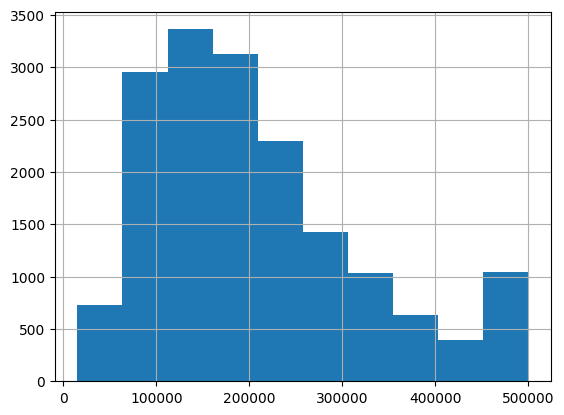

In [3]:
import matplotlib.pyplot as plt

df['median_house_value'].hist()
plt.show()

In [4]:
# create a new target variable for SMOTE
import numpy as np

# nice imbalanced data!
df['median_house_value'] = np.where(df['median_house_value'] < 380000, 1, 0)
df['median_house_value'].value_counts()

,count
median_house_value,
1,15304
0,1696


# (5 pts) Split data into train and test
Remember, your dataset should be split into train and test FIRST so that the test dataset retains the original distribution of 0s and 1s. No SMOTE data in the test partition - your boss only cares about real rows!

In [5]:
# Separate predictors and response variable
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']
print(X.shape, y.shape)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Feature scaling
# Standardizing features improves convergence speed and model stability.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # Fit only on training data to avoid data leakage
X_test_scaled = scaler.transform(X_test)

(17000, 8) (17000,)


# (15 pts) Majority Undersampling
Perform majority undersampling and evaluate model performance (use confusion matrices, classifcation report) and make comments about what you see.

In [6]:
# 1. Define undersampling strategy
undersampler = RandomUnderSampler(sampling_strategy='majority', random_state=42)

# 2. Fit and apply the transform to training data
X_train_resampled, y_train_resampled = undersampler.fit_resample(X_train_scaled, y_train)

# Summarize class distribution
print("Resampled training shape:", Counter(y_train_resampled), "\n")

# 3. Initialize and train the model on the resampled data (MLPClassifier selected, random_state set to default 42)
model = MLPClassifier(random_state=42, max_iter=2000) # max_iter selected from past assignment
model.fit(X_train_resampled, y_train_resampled)

# 4. Evaluate on the test partition with classification report
y_test_pred = model.predict(X_test_scaled)
print("Classification report for majority undersampling:\n")
print(classification_report(y_test, y_test_pred))

# 5. Display confusion matrixes to see distribution for the test set
confusion_matrix_test = confusion_matrix(y_test, y_test_pred)
print("\nConfusion Matrix - Test Set:")
print(confusion_matrix_test)

Resampled training shape: Counter({0: 1344, 1: 1344}) 

Classification report for majority undersampling:

              precision    recall  f1-score   support

           0       0.44      0.90      0.59       352
           1       0.99      0.87      0.92      3048

    accuracy                           0.87      3400
   macro avg       0.71      0.88      0.76      3400
weighted avg       0.93      0.87      0.89      3400


Confusion Matrix - Test Set:
[[ 317   35]
 [ 401 2647]]


**Comments:** Based on the classification report and the accompanying confusion matrix for the test partition with **majority undersampling**, we see that the model was overfit, as it accurately predicted the median house value but struggled to predict otherwise.

# (15 pts) Minority Oversampling
Perform minority oversampling and evaluate model performance (use confusion matrices, classifcation report) and make comments about what you see.

In [7]:
# use imblearn to perform minority oversampling on X_train, evaluate on test partition

# 1. Define undersampling strategy
oversampler = RandomOverSampler(sampling_strategy='minority', random_state=42)

# 2. Fit and apply the transform to training data
X_train_resampled, y_train_resampled = oversampler.fit_resample(X_train_scaled, y_train)

# 3. Summarize class distribution
print("Resampled training shape:", Counter(y_train_resampled), "\n")

# 4. Initialize and train the model on the resampled data (MLPClassifier selected, random_state set to default 42)
model = MLPClassifier(random_state=42, max_iter=2000) # max_iter selected from past assignment
model.fit(X_train_resampled, y_train_resampled)

# 5. Evaluate on the test partition with classification report
y_test_pred = model.predict(X_test_scaled)
print("Classification report for minority oversampling:\n")
print(classification_report(y_test, y_test_pred))

# 6. Display confusion matrixes to see distribution for the test set
confusion_matrix_test = confusion_matrix(y_test, y_test_pred)
print("\nConfusion Matrix - Test Set:")
print(confusion_matrix_test)

Resampled training shape: Counter({0: 12256, 1: 12256}) 

Classification report for minority oversampling:

              precision    recall  f1-score   support

           0       0.49      0.88      0.63       352
           1       0.98      0.89      0.94      3048

    accuracy                           0.89      3400
   macro avg       0.73      0.89      0.78      3400
weighted avg       0.93      0.89      0.90      3400


Confusion Matrix - Test Set:
[[ 310   42]
 [ 329 2719]]


**Comments:** Based on the classification report and the accompanying confusion matrix for the test partition with **minority oversampling**, we see that the model remained overfit, but slight improvements in accuracy, precision, and F-1 score were observed.

# (15 pts) SMOTE
Perform synthetic minority oversampling and evaluate model performance (use confusion matrices, classifcation report) and make comments about what you see.

In [8]:
# use imblearn to perform synthetic minority data on X_train, evaluate on test partition

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# 3. Summarize class distribution
print("Resampled training shape:", Counter(y_train_resampled), "\n")

# 4. Initialize and train the model on the resampled data (MLPClassifier selected, random_state set to default 42)
model = MLPClassifier(random_state=42, max_iter=2000) # max_iter selected from past assignment
model.fit(X_train_resampled, y_train_resampled)

# 5. Evaluate on the test partition with classification report
y_test_pred = model.predict(X_test_scaled)
print("Classification report for SMOTE:\n")
print(classification_report(y_test, y_test_pred))

# 6. Display confusion matrixes to see distribution for the test set
confusion_matrix_test = confusion_matrix(y_test, y_test_pred)
print("\nConfusion Matrix - Test Set:")
print(confusion_matrix_test)

Resampled training shape: Counter({0: 12256, 1: 12256}) 

Classification report for SMOTE:

              precision    recall  f1-score   support

           0       0.51      0.86      0.64       352
           1       0.98      0.90      0.94      3048

    accuracy                           0.90      3400
   macro avg       0.75      0.88      0.79      3400
weighted avg       0.93      0.90      0.91      3400


Confusion Matrix - Test Set:
[[ 304   48]
 [ 292 2756]]


**Comments:** Based on the classification report and the accompanying confusion matrix for the test partition with **SMOTE**, accuracy, precision, and F-1 score had the highest values for the 0 class. Minor to no improvements were achieved otherwise with the utilization of SMOTE.

# (5 pts) Comparison of 3 methods
Out of the three methods, did any do the best? Make a few comments about what you see.

**Answer:** With the results presented above as-is (with no additional hyperparameter tuning or other measures taken), SMOTE performed the best in terms of predicting the 0 class. For the 1 class, SMOTE yielded the best results.

# (40 pts) Reproducibility - run it 30 times or more!
This is one is a little tougher - choose any method and replicate it at least 30 times using a for loop. This means you will split into train and test 30 times (which means you should choose a random_state equal to 'i' as your for loop spins.)

The purpose of this is so that you can show the distribution (hopefully a bell curve but not necessarily) of accuracy, precision and recall. Do some folds get predicted better than others?



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt

accuracies = []
precisions = []
recalls = []

for i in range(30):
    # 1. Train-test split with random_state = i
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=i
    )

    # 2. Feature scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 3. Apply SMOTE to training data
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

    # 4. Initialize and train the model
    model = MLPClassifier(random_state=42, max_iter=2000)
    model.fit(X_train_resampled, y_train_resampled)

    # 5. Make predictions and calculate metrics
    y_test_pred = model.predict(X_test_scaled)

    accuracies.append(accuracy_score(y_test, y_test_pred))
    precisions.append(precision_score(y_test, y_test_pred, pos_label=0))
    recalls.append(recall_score(y_test, y_test_pred, pos_label=0))

    print(f"Iteration {i+1}/30 completed.")

# Plot the distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(accuracies, bins=10, color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Accuracy')
axes[0].set_xlabel('Accuracy')

axes[1].hist(precisions, bins=10, color='salmon', edgecolor='black')
axes[1].set_title('Distribution of Precision (Class 0)')
axes[1].set_xlabel('Precision')

axes[2].hist(recalls, bins=10, color='lightgreen', edgecolor='black')
axes[2].set_title('Distribution of Recall (Class 0)')
axes[2].set_xlabel('Recall')

plt.tight_layout()
plt.show()

Iteration 1/30 completed.
Iteration 2/30 completed.
Iteration 3/30 completed.
Iteration 4/30 completed.
Iteration 5/30 completed.
Iteration 6/30 completed.
Iteration 7/30 completed.
Iteration 8/30 completed.
Iteration 9/30 completed.
Iteration 10/30 completed.


# (5 pts) Comments on the repeated experiment
Make some comments about what you saw! Feel free to run 100 or 1000 times if it runs fast enough 😏

Based on the results of these histograms, we see an overall high accuracy in the very high 80s and low 90s. Precision remains not only significantly lower but also with increased variation (.46 to .58). This model performs well but struggles with false positives. Recall remains between .80 and .91, signaling SMOTE's approach is the best out of the three and helps to identify high-valued homes in the minority class.